# Build a machine learning model for classifying the Iris flowers


### Task description

Well, popular as the first dataset to try when learning machine learning. A dataset with comprehensible attributes and manageable size.

The problem is to classify a Iris flower into a sub-categories based on its sepal and petal length and width.

A dataset is provided and can be downloaded from the following source. Alternatively, you may use Pandas read_csv() function to load it directly from the link.

data Source: "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"

This dataset contains following attributes as columns.

Attributes list as features:
'sepal-length', 'sepal-width', 'petal-length', 'petal-width',

and target variable as 'class' .

Similar to the lab, please perform the following tasks on the way to build and evaluate a classfification model.

1. Load the data.
2. Seperate features and label; X and Y
3. Normalize if you need to.
4. split into train and test set
5. Build machine learning model using Logistic Regression. print the classification report on test data.
6. Build Decision Tree and Random Forest and Neural Network Model to compare the performance.
7. Write your conclusion on the performance.

## This assignment carries 100 points which is splitted between different questions here. Please use the notebook to complete the task and then submit it in blackboard for assessment.


### Import packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Load the data.

In [2]:
import pandas as pd

iris = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv',
    names=['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
)

iris.head()

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Seperate data into features and label: X and Y.

10 points for this part

In [3]:
X = iris[['sepal-length', 'sepal-width', 'petal-length', 'petal-width']]
y = iris['class']

print("Features:")
print(X.head())

print("\nLabels:")
print(y.head())

Features:
   sepal-length  sepal-width  petal-length  petal-width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Labels:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: object


### Normalize if you need to.

In [5]:
from sklearn.preprocessing import StandardScaler

# sacaling the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]]


### split into train and test set.

10 points for this part

In [7]:
from sklearn.model_selection import train_test_split

# spliting data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### Build machine learning model using Logistic Regression. print the classification report on test data.

10 points for this part

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9333333333333333

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



### Build Decision Tree(DT) and Random Forest(RF) and Neural Network(NN) Model to compare the performance.

30 points for this part

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Neural Network
nn_model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

Decision Tree Accuracy: 0.9
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

Random Forest Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Neural Network Accuracy: 0.9666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1

### Perform 5 fold cross validation between the DT, RF, and NN and make a diagram based on the accuracy of these different models. Finally write your conclusion on the performance.

40 points for this part

Decision Tree CV Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Random Forest CV Scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Neural Network CV Scores: [0.96666667 1.         0.9        0.93333333 1.        ]

Mean Accuracies
Decision Tree: 0.9533333333333334
Random Forest: 0.96
Neural Network: 0.96


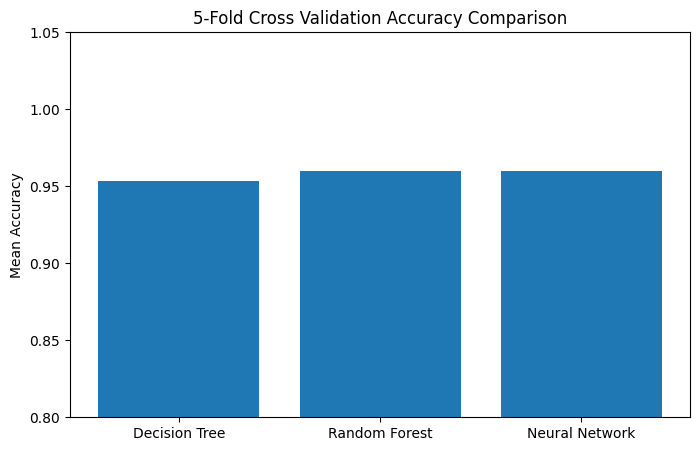

In [13]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

dt_scores = cross_val_score(dt_model, X_scaled, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='accuracy')
nn_scores = cross_val_score(nn_model, X_scaled, y, cv=5, scoring='accuracy')

print("Decision Tree CV Scores:", dt_scores)
print("Random Forest CV Scores:", rf_scores)
print("Neural Network CV Scores:", nn_scores)

print("\nMean Accuracies")
print("Decision Tree:", dt_scores.mean())
print("Random Forest:", rf_scores.mean())
print("Neural Network:", nn_scores.mean())

models = ['Decision Tree', 'Random Forest', 'Neural Network']
mean_scores = [dt_scores.mean(), rf_scores.mean(), nn_scores.mean()]

plt.figure(figsize=(8,5))
plt.bar(models, mean_scores)
plt.ylabel("Mean Accuracy")
plt.title("5-Fold Cross Validation Accuracy Comparison")
plt.ylim(0.8, 1.05)
plt.show()

# Conclusion

All three models, Decision Tree, Random Forest and Neural Network produced similar results when classifiying the iris dataset. Even though their performance was very close there were a few small differences between then. The Random FOrest model performed slightly better and a bit more consistent becuase it combines multiple decision trees, which helpd to reduce the chances of overfitting. The Decision Tree model also worked well and has the advantage of being easier to understand and visualize, though it can sometimes fit the training data too closely. The Neural Network also showed strong accuracy and is especially useful for more complex problems, but its benefits are not as noticeable with a simple dataset like this one. Overall, all three models did a good job, but Random Forest showed the most stable performance across the tests.